# Does size matter?

A frequent point made in discussions of bass speakers is: *Driver size doesn't matter." This is both agreed upon as a basic truism, and rejected as a myth.

When confronted with such a controversy, my gut reaction is to figure out what's actually happening under the hood. Perhaps a more precise statement of the myth will turn it into a truism, or maybe vice versa.

In [1]:
from numpy import *
from matplotlib.pyplot import *
import pandas as pd

In [2]:
# Physical constants

gamma = 1.4 # adiabatic constant, dimensionless
P_atm = 101325 # atmospheric pressure, Pa
rho = 1.225 # density of air, kg/m^3
c = sqrt(gamma*P_atm/rho) # https://en.wikipedia.org/wiki/Speed_of_sound
P_ref = 1 # reference power in Watts
R = 1 # listening distance in meters

f = logspace(1, 3, 300) # a range of frequencies from 10 to 1000 Hz
style = 'Francis' # preferred style is 'Francis', use 'WinISD to compare results with the WinISD software'

def xCone(w = 2*pi*f, 
          F_s = 37, # free air resonance in Hz
          R_e= 5.04, # series resistance of voice coil in Ohms
          L_e = 0.46*0.001, # inductance of voice coil converted from mH to H
          Q_ms = 3.13, # mechanical contribution to Q factor
          Q_es = 0.44, # electromagnetic contribution to Q factor
          Vas = 147*0.001, # equivalent box volume, liters converted to m^3
          Xmax = 4.90*0.001, # maximum excursion, converted from mm to m
          S_d = 519.5/1e4, # cone area converted from cm^2 to m^2
          
          Znom = 8,
          Pin = 100, # input power used for calculations like cone excursion and port air speed
          V_box = 32*1e-3, # box volume, 32 l converted to m^3
          ported = True,
          f_port = 40, # port tuning frequency in Hz
          Q_port = 50,
          portShape = 'rectangular', # circular or rectangular
          d_port = 100*0.01, # diameter of port if circular in cm converted to m
          a_port = 3.5*0.01, # width of port if rectangular
          b_port = 21.5*0.01, # height of port if rectangular
          endCorrect = 0.732, # port end correction factor
          initReport = {},
          design = '',
         ):
    
    '''
    Compute cone excursion and other performance measures
    
    Parameters are self explanatory, all are in SI units
    '''
    
    w_0 = 2*pi*F_s # resonant frequency in radians/s
    m = gamma*P_atm*S_d**2/w_0**2/Vas # cone mass in kg
    BL = sqrt(w_0*m*R_e/Q_es) # BL product in T*m
    C = w_0*m/Q_ms # Mechanical damping constant of cone
    K = w_0**2*m # Spring constant of cone
    r = sqrt(S_d/pi) # Radius
    z = R_e + 1j*w*L_e # Electrical impedance
    K_box = gamma*P_atm*S_d**2/V_box # Spring constant of box
    if style == 'WinISD':
        Vin = sqrt(Pin*R_e) # Input voltage in Volts RMS
    elif style == 'Francis':
        Vin = sqrt(Pin*Znom) # Input voltage in Volts RMS
    else:
        print('style must be winISD or Francis')
    Vref = sqrt(P_ref*Znom) # Input voltage in Volts RMS
        
    if ported:
        w_port = 2*pi*f_port # port resonant frequency in radians/s
        kappa = w**2/(w**2 - 1j*w*w_port/Q_port - w_port**2) # correction factor for box spring constant based on port behavior
    else:
        kappa = 1 # i.e., no port therefore no port correction

    Keff = K + kappa*K_box # total spring constant, from driver suspension plus port-corrected box
    
    x = BL*Vin/m/z/(Keff/m + 1j*w*(BL**2/m/z + C/m) - w**2) # cone excursion amplitude in meters

    Z = z/(1 - 1j*w*BL*x/Vin) # cone impedance, complex valued, in Ohms

    p = rho*r**2*w**2*kappa*x/R/2 # sound pressure amplitude in Pascal

    p_ref = 20e-6 # reference value for sound pressure, in Pascal
    spl = 20*log10(abs(p)/p_ref) # sound pressure level in dB SPL
    
    phaseRot = 180*pi/180 # phase rotation for phase graph, to make it agree with WinISD
    phase = angle(p*(cos(phaseRot) + 1j*sin(phaseRot)))*180/pi # phase of acoustic wavefront, nearfield
     
    # More ported behavior
    
    if ported:
        kappa2 = w_port**2/(w**2 - 1j*w*w_port/Q_port - w_port**2)
        
        if portShape == 'circular':
            S_port = pi*d_port**2/4
            Rport = d_port/2
        elif portShape == 'rectangular': 
            S_port = a_port*b_port
            Rport = min([a_port, b_port])/2 # assume effective radius is the smaller of the two dimensions
        else:
            print('portShape needs to be circular or rectangular')
        
        v_port = 1j*w*kappa2*x*S_d/S_port/c # speed of port air plug
        
        lport = S_port*gamma*P_atm/rho/V_box/w_port**2 - Rport*2*endCorrect # length of port in meters
        
    else:
        v_port = None
        
    report = dict(initReport)
    report['Q_tc'] = 1/(1/Q_es + 1/Q_ms)*np.sqrt(Vas/V_box + 1) # total Q of system, from driver and box
    report['resonant angular frequency w_0 (1/s)'] = w_0
    report['cone mass m (kg)'] = m
    report['magnetic field length product BL (T m)'] = BL
    report['mechanical damping factor (N/(m/s))'] = C
    report['mechanical spring constant (N/m)'] = K
    report['mechanical compliance (m/N)'] = 1/K
    report['cone radius (m)'] = r
    report['box spring constant (N/m)'] = K_box
    report['Port angular frequency (1/s)'] = w_port
    report['Port area (m^2)'] = S_port
    report['Port effective radius (m)'] = Rport
    report['Length of port (m)'] = lport
    report['Length of port (in)'] = lport*39.3
        
    return x, Z, spl, phase, v_port, p, pd.DataFrame([[tag, report[tag]] for tag in report])

def graphs(f, x, xmax, Z, spl, phase, v_port, label, ax):
    ax[0].semilogx(f, abs(x)*1000*1.414, label = label)
    last_line = ax[0].get_lines()[-1]
    line_color = last_line.get_color() # Retrieve the color of the line
    ax[0].axhline(xmax*1000, color = line_color, linestyle = '--',)
    ax[0].set_ylabel('cone excursion amplitude (mm)')
    
    ax[1].semilogx(f, abs(Z), label = label)
    ax[1].set_ylabel(r'impedance ($\Omega$)')

    ax[2].semilogx(f, spl, label = label)
    ax[2].set_ylabel('Sound pressure (dB SPL)')

    ax[3].semilogx(f, phase, label = label)
    ax[3].set_ylabel('Phase')

    ax[4].semilogx(f, abs(v_port)*1.414, label = label)
    ax[4].set_xlabel('frequency (Hz)')
    ax[4].set_ylabel('port air speed (mach)')
    
    for a in ax:
        a.set_xticks([20, 40, 60, 100, 200, 400, 600])
        a.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
        a.legend()
    
def runGraph(name, driver, box, ax):
    x, Z, spl, phase, v_port, p1, df = xCone(**(name | driver | box), initReport = name | driver | box)
    label = name['design']
    graphs(f, x, driver['Xmax'], Z, spl, phase, v_port, label, ax)
    return df

## Driver and box database

You can add more if you want!

In [5]:
# Driver library.

emi3012ho = { # Eminence DeltaLite 3012HO
    'F_s': 52, # resonant frequency in Hz
    'R_e': 5.5, # series resistance of voice coil in Ohms
    'L_e': 0.57*0.001, # inductance of voice
    'Q_ms': 8.39, # mechanical contribution to Q factor
    'Q_es': 0.33, # electromagnetic contribution to Q factor
    'Vas': 81.1*0.001, # equivalent box volume, liters converted
    'Xmax': 6.20*0.001, # maximum excursion, converted from mm to m
    'S_d': 532.4/1e4, # cone area converted from cm^2 to m^2
}

tcp115_4 = { # Dayton Audio TCP115-4
    'F_s': 53.8, # resonant frequency in Hz
    'R_e': 3.2, # series resistance of voice coil in Ohms
    'L_e': 0.97*0.001, # inductance of voice coil converted from mH to H
    'Q_ms': 3.14, # mechanical contribution to Q factor
    'Q_es': 0.40, # electromagnetic contribution to Q factor
    'Vas': 3.1*0.001, # equivalent box volume, liters converted to m^3
    'Xmax': 4.0*0.001, # maximum excursion, converted from mm to m
    'S_d': 50.3/1e4, # cone area converted from cm^2 to m^2
}

emi2512ii = { # Eminence DeltaLite 2512-ii
    'F_s': 37, # resonant frequency in Hz
    'R_e': 5.04, # series resistance of voice coil in Ohms
    'L_e': 0.46*0.001, # inductance of voice coil converted from mH to H
    'Q_ms': 3.13, # mechanical contribution to Q factor
    'Q_es': 0.44, # electromagnetic contribution to Q factor
    'Vas': 147*0.001, # equivalent box volume, liters converted to m^3
    'Xmax': 4.90*0.001, # maximum excursion, converted from mm to m
    'S_d': 519.5/1e4, # cone area converted from cm^2 to m^2
}

fp8pr200 = { # Faital Pro 8PR200
    'F_s': 58, # resonant frequency in Hz
    'R_e': 5.1, # series resistance of voice coil in Ohms
    'L_e': 0.55*0.001, # inductance of voice coil converted from mH to H
    'Q_ms': 9.4, # mechanical contribution to Q factor
    'Q_es': 0.38, # electromagnetic contribution to Q factor
    'Vas': 16.9*0.001, # equivalent box volume, liters converted to m^3
    'Xmax': 8.15*0.001, # maximum excursion, converted from mm to m
    'S_d': 209/1e4, # cone area converted from cm^2 to m^2
}

fp8PR320 = { # Faital Pro 8PR320
    'F_s': 65, # resonant frequency in Hz
    'R_e': 5.4, # series resistance of voice coil in Ohms
    'L_e': 0.52*0.001, # inductance of voice coil converted from mH to H
    'Q_ms': 8.2, # mechanical contribution to Q factor
    'Q_es': 0.41, # electromagnetic contribution to Q factor
    'Vas': 13.1*0.001, # equivalent box volume, liters converted to m^3
    'Xmax': 7.33*0.001, # maximum excursion, converted from mm to m
    'S_d': 223/1e4, # cone area converted from cm^2 to m^2
}

# Box database

box1 = { # My little 12" box
    'Znom': 8,
    'Pin': 100,
    'V_box': 32*1e-3, # box volume, 32 l converted to m^3
    'ported': True,
    'f_port': 40, # port tuning frequency in Hz
    'Q_port': 10, # value borrowed from WinISD
    'portShape': 'rectangular', # circular or rectangular
    'd_port': None, # diameter of port if circular in cm converted to m
    'a_port': 3.5*0.01, # width of port if rectangular
    'b_port': 21.5*0.01, # height of port if rectangular
    'endCorrect': 0.732, # port end correction factor
}

box2 = {
    'Znom': 8,
    'Pin': 100,
    'V_box': 15*1e-3, # box volume, 32 l converted to m^3
    'ported': True,
    'f_port': 40, # port tuning frequency in Hz
    'Q_port': 10, # value borrowed from WinISD
    'portShape': 'rectangular', # circular or rectangular
    'd_port': None, # diameter of port if circular in cm converted to m
    'a_port': 5.5*0.01, # width of port if rectangular
    'b_port': 5.5*0.01, # height of port if rectangular
    'endCorrect': 0.732, # port end correction factor
}

box3 = {
    'Znom': 8,
    'Pin': 100,
    'V_box': 15*1e-3, # box volume, 32 l converted to m^3
    'ported': True,
    'f_port': 45, # port tuning frequency in Hz
    'Q_port': 10, # value borrowed from WinISD
    'portShape': 'rectangular', # circular or rectangular
    'd_port': None, # diameter of port if circular in cm converted to m
    'a_port': 5.5*0.01, # width of port if rectangular
    'b_port': 5.5*0.01, # height of port if rectangular
    'endCorrect': 0.732, # port end correction factor
}

box4 = {
    'Znom': 8,
    'Pin': 100,
    'V_box': 15*1e-3, # box volume, 32 l converted to m^3
    'ported': True,
    'f_port': 40, # port tuning frequency in Hz
    'Q_port': 100, # value borrowed from WinISD
    'portShape': 'rectangular', # circular or rectangular
    'd_port': None, # diameter of port if circular in cm converted to m
    'a_port': 6.35*0.01, # width of port if rectangular
    'b_port': 6.35*0.01, # height of port if rectangular
    'endCorrect': 0.732, # port end correction factor
}

box5 = {
    'Znom': 8,
    'Pin': 100,
    'V_box': 81.1*1e-3, # box volume, 32 l converted to m^3
    'ported': True,
    'f_port': 40, # port tuning frequency in Hz
    'Q_port': 100, # value borrowed from WinISD
    'portShape': 'rectangular', # circular or rectangular
    'd_port': None, # diameter of port if circular in cm converted to m
    'a_port': 6.35*0.01, # width of port if rectangular
    'b_port': 6.35*0.01, # height of port if rectangular
    'endCorrect': 0.732, # port end correction factor
}

box6 = {
    'Znom': 4,
    'Pin': 15,
    'V_box': 3.1*1e-3, # box volume, 32 l converted to m^3
    'ported': True,
    'f_port': 40, # port tuning frequency in Hz
    'Q_port': 100, # value borrowed from WinISD
    'portShape': 'rectangular', # circular or rectangular
    'd_port': None, # diameter of port if circular in cm converted to m
    'a_port': 6.35*0.01, # width of port if rectangular
    'b_port': 6.35*0.01, # height of port if rectangular
    'endCorrect': 0.732, # port end correction factor,
}

## Brief analysis of designs

I've got the original 1x8 that I built, including the original design intent and a model with the measured value of the port tuning frequency. Then I modeled the speaker that I was planning on making. I also included a Faital 8PR320 driver, just to see if it performs any better for my use. It doesn't.

,0,1,2
0,design,3012HO,tcp115_4
1,F_s,52,53.8
2,R_e,5.5,3.2
3,L_e,0.00057,0.00097
4,Q_ms,8.39,3.14
5,Q_es,0.33,0.4
6,Vas,0.0811,0.0031
7,Xmax,0.0062,0.004
8,S_d,0.05324,0.00503
9,Znom,8,4


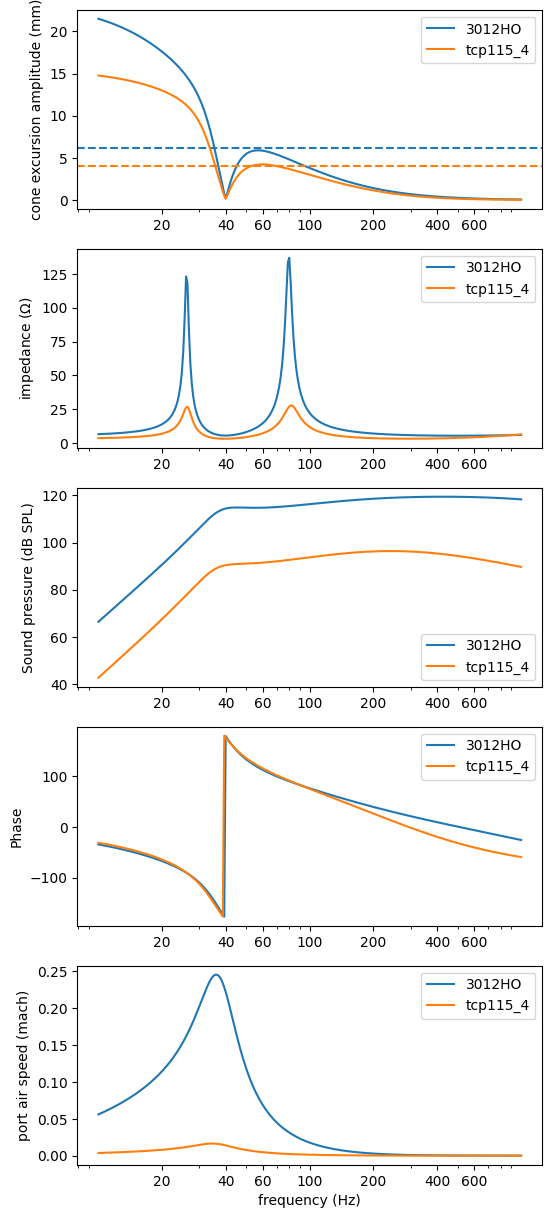

In [6]:
fig, ax = subplots(5, 1, figsize = (6, 15))

df1 = runGraph({'design': '3012HO'}, emi3012ho, box5, ax)
df2 = runGraph({'design': 'tcp115_4'}, tcp115_4, box6, ax)
#df3 = runGraph({'design': '1x8 proposed'}, fp8pr200, box4, ax)
#df4 = runGraph({'design': '1x8 using 8PR320'}, fp8PR320, box4, ax)
df1[2] = df2[1]
#df1[3] = df3[1]
#df1[4] = df4[1]
display(df1)